In [1]:
import json
import matplotlib.pyplot as plt
from matplotlib import rc
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
import numpy as np
import os

/var/folders/p4/5739skqd2071x3f05l7p2mcm0000gn/T/ipykernel_47836/3816625661.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


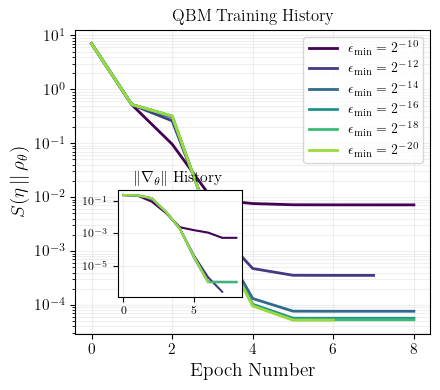

In [2]:
# ------------------------------------------------------------------
# 1. STYLE CONFIGURATION (Single-Column LaTeX)
# ------------------------------------------------------------------
# Enable LaTeX rendering for all text
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

# Define font sizes optimized for a single-column (~3.5 inch) figure
LABEL_SIZE = 14
TITLE_SIZE = 12
TICK_SIZE = 11
LEGEND_SIZE = 10

# ------------------------------------------------------------------
# 2. LOAD DATA
# ------------------------------------------------------------------
filename = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data/learn_temperature/qbm_optimization_N12_20260127_185450.json"

with open(filename, 'r') as f:
    all_results = json.load(f)

runs = all_results["runs"]
# Sort runs by min_abs_coeff descending for consistent coloring
runs = sorted(runs, key=lambda x: x["min_abs_coeff"], reverse=True)
num_runs = len(runs)

# ------------------------------------------------------------------
# 3. CREATE FIGURE
# ------------------------------------------------------------------
# Standard single-column width is ~3.3-3.5 inches. 
# We use a 4:3 aspect ratio (4" x 4") to keep it compact.
fig, ax1 = plt.subplots(figsize=(4.5, 4.0))

# Create the inset axes in the bottom-left area (specified by bbox_to_anchor)
# bbox_to_anchor=(x_origin, y_origin, width, height) in axis fractions
ax_inset = inset_axes(ax1, width="35%", height="35%", loc='lower left', 
                      bbox_to_anchor=(0.1, 0.1, 1, 1), bbox_transform=ax1.transAxes)

# Define the dynamic color gradient (Viridis)
colors = plt.cm.viridis(np.linspace(0, 0.85, num_runs))

# ------------------------------------------------------------------
# 4. POPULATE PLOTS
# ------------------------------------------------------------------
for i, run in enumerate(runs):
    # Calculate exponent for the LaTeX legend
    exponent = int(np.round(np.log2(run["min_abs_coeff"])))
    label = rf"$\epsilon_{{\min}} = 2^{{{exponent}}}$"
    
    # Main Plot: Quantum Relative Entropy S(η||ρθ)
    ax1.plot(run["f_trace"], color=colors[i], label=label, linewidth=2.0)
    
    # Inset Plot: Gradient Norm ||∇θ||
    ax_inset.plot(run["g_norm_trace"], color=colors[i], linewidth=1.5)

# ------------------------------------------------------------------
# 5. AESTHETICS & FORMATTING
# ------------------------------------------------------------------

# Main Plot Formatting
ax1.set_yscale('log')
ax1.set_xlabel(r'Epoch Number', fontsize=LABEL_SIZE)
ax1.set_ylabel(r'$S(\eta \, || \, \rho_{\theta})$', fontsize=LABEL_SIZE)
ax1.set_title(r'QBM Training History', fontsize=TITLE_SIZE)
ax1.tick_params(axis='both', which='major', labelsize=TICK_SIZE)
ax1.legend(loc='upper right', fontsize=LEGEND_SIZE, frameon=True)
ax1.grid(True, which="both", ls="-", alpha=0.2)

# Inset Plot Formatting
ax_inset.set_yscale('log')
ax_inset.set_title(r'$\|\nabla_{\theta}\|$ History', fontsize=TICK_SIZE)
ax_inset.tick_params(axis='both', which='major', labelsize=TICK_SIZE-3)
ax_inset.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()

# Save for the manuscript
plt.savefig("QBM_Training_Python.pdf", bbox_inches='tight')
plt.show()

/var/folders/p4/5739skqd2071x3f05l7p2mcm0000gn/T/ipykernel_47836/1823551800.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


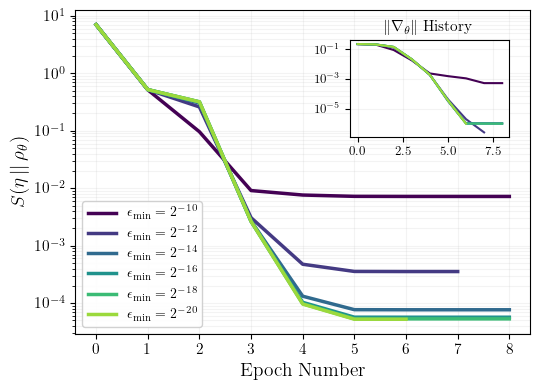

In [17]:

# ------------------------------------------------------------------
# 1. STYLE CONFIGURATION
# ------------------------------------------------------------------
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

LABEL_SIZE = 14
TITLE_SIZE = 12
TICK_SIZE = 11
LEGEND_SIZE = 10

# ------------------------------------------------------------------
# 2. LOAD DATA
# ------------------------------------------------------------------
filename = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data/learn_temperature/qbm_optimization_N12_20260127_185450.json"

with open(filename, 'r') as f:
    all_results = json.load(f)

runs = sorted(all_results["runs"], key=lambda x: x["min_abs_coeff"], reverse=True)
num_runs = len(runs)

# ------------------------------------------------------------------
# 3. CREATE FIGURE (Adjusted for Inset Space)
# ------------------------------------------------------------------
# We slightly increase the height (4.5, 5.0) to give the curves room to settle
fig, ax1 = plt.subplots(figsize=(5.5, 4.0))

# OPTION: Move inset to Top-Right (loc=1) or Bottom-Left (loc=3)
# Here we use loc='upper right' and adjust bbox_to_anchor to prevent line overlap
ax_inset = inset_axes(ax1, width="35%", height="30%", loc='upper right', 
                      bbox_to_anchor=(-0.03, -0.07, 1, 1), bbox_transform=ax1.transAxes)

colors = plt.cm.viridis(np.linspace(0, 0.85, num_runs))

# ------------------------------------------------------------------
# 4. POPULATE PLOTS
# ------------------------------------------------------------------
for i, run in enumerate(runs):
    exponent = int(np.round(np.log2(run["min_abs_coeff"])))
    label = rf"$\epsilon_{{\min}} = 2^{{{exponent}}}$"
    
    ax1.plot(run["f_trace"], color=colors[i], label=label, linewidth=2.5)
    ax_inset.plot(run["g_norm_trace"], color=colors[i], linewidth=1.5)

# ------------------------------------------------------------------
# 5. AESTHETICS & LEGEND PLACEMENT
# ------------------------------------------------------------------
ax1.set_yscale('log')
ax1.set_xlabel(r'Epoch Number', fontsize=LABEL_SIZE)
ax1.set_ylabel(r'$S(\eta \, || \, \rho_{\theta})$', fontsize=LABEL_SIZE)
# ax1.set_title(r'QBM Training, Heisenberg 2D, 12 qubits', fontsize=TITLE_SIZE)

# Move legend to 'lower left' so it doesn't fight with the Top-Right inset
ax1.legend(loc='lower left', fontsize=LEGEND_SIZE, frameon=True, framealpha=0.9)
ax1.grid(True, which="both", ls="-", alpha=0.15)
ax1.tick_params(axis='both', which='major', labelsize=TICK_SIZE)

# Inset Formatting
ax_inset.set_yscale('log')
ax_inset.set_title(r'$\|\nabla_{\theta}\|$ History', fontsize=TICK_SIZE)
ax_inset.tick_params(axis='both', which='major', labelsize=TICK_SIZE-2)
ax_inset.grid(True, which="both", ls="-", alpha=0.15)

# Increase the Y-limit slightly to create whitespace for the inset if necessary
# current_ylim = ax1.get_ylim()
# ax1.set_ylim(current_ylim[0], current_ylim[1] * 5) 

plt.tight_layout()
plt.savefig("QBMtrain_Heis2D_12qb.pdf", bbox_inches='tight')
plt.show()

...Successfully processed data for β=0.1.
...Successfully processed data for β=1.0.
...Successfully processed data for β=5.0.
...Successfully processed data for β=20.0.
...Successfully processed data for β=50.0.


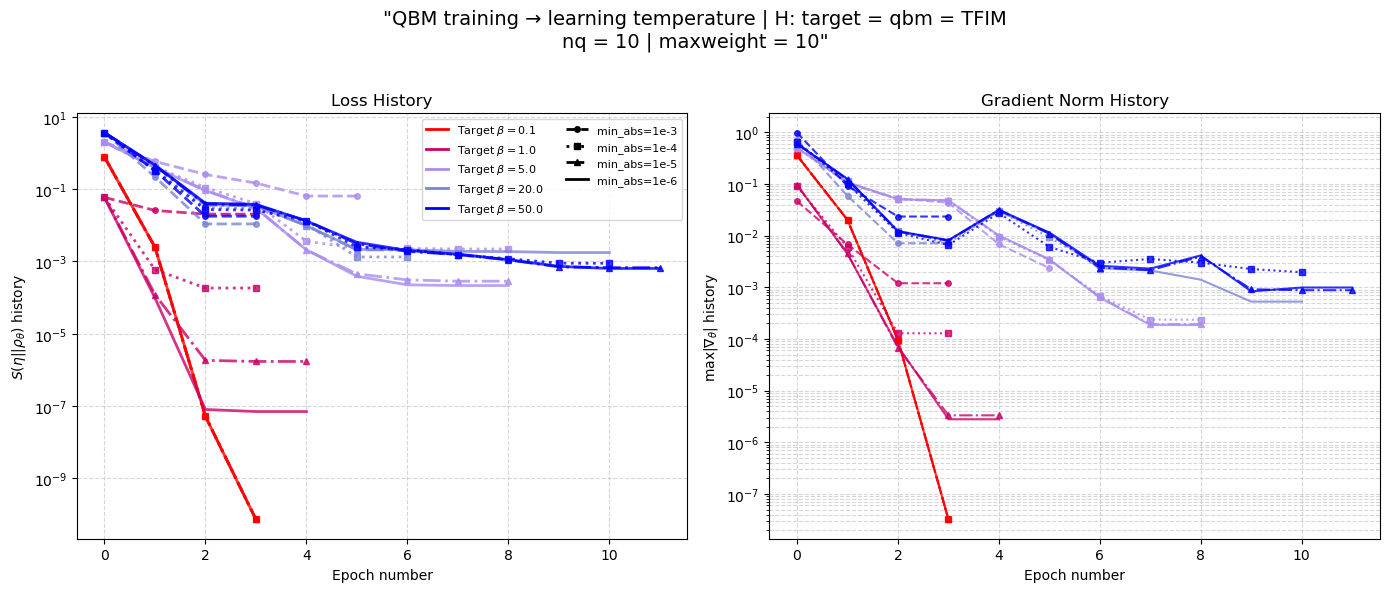

In [5]:
# --- 1. Define File and Style Maps ---

FILE_MAP = {
    0.1: ("qbm_optimization_N10_B0.1_20251203_133817.json", 'red'),
    1.0: ("qbm_optimization_N10_B1_20251203_093021.json", '#CC0066'),  # Reddish-Magenta
    5.0: ("qbm_optimization_N10_B5_20251203_133912.json", '#A98CEE'),  # Soft Purple
    20.0: ("qbm_optimization_N10_B20_20251203_134640.json", '#7C84D4'),  # Periwinkle
    50.0: ("qbm_optimization_N10_B50_20251203_102817.json", 'blue')
}

COEFF_STYLES = {
    1.0e-3: {'linestyle': '--', 'marker': 'o', 'ms': 4, 'lw': 2, 'label': 'min_abs=1e-3'},
    1.0e-4: {'linestyle': ':', 'marker': 's', 'ms': 4, 'lw': 2, 'label': 'min_abs=1e-4'},
    1.0e-5: {'linestyle': '-.', 'marker': '^', 'ms': 4, 'lw': 2, 'label': 'min_abs=1e-5'},
    1.0e-6: {'linestyle': '-', 'marker': 'None', 'ms': 0, 'lw': 2, 'label': 'min_abs=1e-6'}
}

BASE_DIR = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data/learn_temperature"

# Sort keys for consistent plotting order (low beta to high beta)
beta_keys = sorted(FILE_MAP.keys())
all_data = [] # List to store all parsed data

# --- 2. Data Loading Function ---

def load_data():
    """Loads and parses all JSON files."""
    for beta in beta_keys:
        filename_base, beta_color = FILE_MAP[beta]
        filename = os.path.join(BASE_DIR, filename_base)
        
        try:
            with open(filename, 'r') as f:
                # Python's json library is generally robust with numeric arrays
                data = json.load(f)
            
            # 💡 NOTE: We are relying on the dictionary structure here
            runs = data['runs']
            
            for run in runs:
                min_coeff = run['min_abs_coeff']
                style = COEFF_STYLES[min_coeff]
                
                # Store all necessary plotting data
                all_data.append({
                    'beta': beta,
                    'color': beta_color,
                    'min_coeff': min_coeff,
                    'style': style,
                    'f_trace': np.array(run['f_trace']),
                    'g_norm_trace': np.array(run['g_norm_trace'])
                })
            print(f"...Successfully processed data for β={beta}.")
            
        except FileNotFoundError:
            print(f"WARNING: File not found for β={beta}: {filename_base}. Skipping.")
        except json.JSONDecodeError as e:
            print(f"ERROR: Failed to parse JSON for β={beta}: {e}. Skipping.")
        except Exception as e:
            print(f"ERROR: An unexpected error occurred for β={beta}: {e}. Skipping.")

# --- 3. Plotting Function ---

def plot_comparison(data):
    """Generates the combined plot using matplotlib."""
    
    # Setup Figure and Axes
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(
        '"QBM training → learning temperature | H: target = qbm = TFIM\nnq = 10 | maxweight = 10"',
        fontsize=14
    )

    # --- Plot 1: Loss History (S(eta || rho)) ---
    
    # Plot all 20 lines
    for run in data:
        # Use an X-axis of integers (epochs)
        epochs = np.arange(len(run['f_trace']))
        
        ax1.plot(
            epochs, run['f_trace'], 
            label=f"$\\beta={run['beta']}$ (min:{run['min_coeff']:.1e})",
            color=run['color'],
            linewidth=run['style']['lw'],
            linestyle=run['style']['linestyle'],
            marker=run['style']['marker'],
            markersize=run['style']['ms'],
            alpha=0.8
        )

    ax1.set_yscale('log')
    ax1.set_xlabel('Epoch number')
    ax1.set_ylabel(r'$S(\eta || \rho_\theta)$ history')
    ax1.set_title('Loss History')
    ax1.grid(True, which="both", ls="--", alpha=0.5)
    
    # Ensure X-axis labels are integers
    ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    
    
    # --- Plot 2: Gradient Norm History ---
    
    for run in data:
        epochs = np.arange(len(run['g_norm_trace']))
        
        ax2.plot(
            epochs, run['g_norm_trace'], 
            color=run['color'],
            linestyle=run['style']['linestyle'],
            marker=run['style']['marker'],
            markersize=run['style']['ms'],
            alpha=0.8
        )
        
    ax2.set_yscale('log')
    ax2.set_xlabel('Epoch number')
    ax2.set_ylabel(r'$\max |\nabla_\theta|$ history')
    ax2.set_title('Gradient Norm History')
    ax2.grid(True, which="both", ls="--", alpha=0.5)
    ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))


    # --- 4. Custom Legend Generation (Applied to ax1) ---
    
    # We must generate two separate sets of handles for the legend
    
    # A. Color Legend (for Beta values)
    color_handles = []
    for beta in beta_keys:
        _, color = FILE_MAP[beta]
        label = f"Target $\\beta={beta:.1f}$"
        # Create an invisible line to serve as the legend entry
        color_handles.append(Line2D([0], [0], color=color, lw=2, label=label))
        
    # B. Style Legend (for Min Coeff values)
    style_handles = []
    for min_coeff in COEFF_STYLES:
        style = COEFF_STYLES[min_coeff]
        label = style['label']
        # Create an invisible line with the required linestyle/marker
        style_handles.append(Line2D([0], [0], color='black', lw=style['lw'], 
                                   linestyle=style['linestyle'], marker=style['marker'], 
                                   markersize=style['ms'], label=label))

    # Combine and display the full legend
    ax1.legend(
        handles=color_handles + style_handles, 
        loc='upper right', 
        fontsize=8,
        ncol=2, # Use two columns to fit everything
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout for suptitle
    plt.show()

# --- Execution ---
load_data()
if all_data:
    plot_comparison(all_data)
else:
    print("No data was successfully loaded. Check file paths and JSON content.")